# Выбор локации для скважины

## Описание проекта

**Заказчик:** Нефтедобывающая компания «ГлавРосГосНефть».

**Цель:** Нужно решить, где бурить новую скважину. 

**Задачи:**
1. Построить модель машинного обучения, которая поможет определить регион, где добыча нефти принесет наибольшую прибыль.
2. Проанализировать возможную прибыль и риски техникой *Bootstrap*.

**Шаги для выбора локации:**
- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

**Данные:** Данные синтетические. Предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. 
- `id` — уникальный идентификатор скважины;
- `f0, f1, f2` — три значимых признака точек;
- `product` — объём запасов в скважине (тыс. баррелей).

**Условия задачи**:
- Для обучения модели подходит только линейная регрессия (остальные — недостаточно предсказуемые).
- При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки.
- Бюджет на разработку скважин в регионе — 10 млрд рублей.
- При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей.
- После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.

## Начало работы

In [1]:
!pip install phik -q

In [2]:
!pip install --upgrade numpy==1.24.4 matplotlib==3.9.0 seaborn==0.13.2 scikit-learn==1.5.2 -q

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import numpy as np

from phik import phik_matrix
from phik.report import plot_correlation_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

RANDOM_STATE = 42

## Загрузка и подготовка данных

In [4]:
try:
    geo_0 = pd.read_csv('geo_data_0.csv')
    
except:
    geo_0 = pd.read_csv('https://code.s3.yandex.net//datasets/geo_data_0.csv') 

geo_0.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


---

In [5]:
try:
    geo_1 = pd.read_csv('geo_data_1.csv')
    
except:
    geo_1 = pd.read_csv('https://code.s3.yandex.net//datasets/geo_data_1.csv') 

geo_1.head()

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


---

In [6]:
try:
    geo_2 = pd.read_csv('geo_data_2.csv')
    
except:
    geo_2 = pd.read_csv('https://code.s3.yandex.net//datasets/geo_data_2.csv') 

geo_2.head()

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


## Предобработка

Создадим функцию, которая выведет основную информацию о датафрейме:
- Размер
- Кол-во строк дубликатов
- Тип значений в столбцах
- Кол-во ненулевых значений
- Кол-во уникальных значений
- Список уникальных значений
- Кол-во нулей в данных

In [7]:
def df_info(df):
    df_ = pd.DataFrame(
        index = df.columns,
        data = {
            "dtype": [df[col].dtype for col in df.columns],
            "non_NA": [df[col].notna().sum() for col in df.columns],
            "unique_count": [df[col].nunique() for col in df.columns],
            "unique_values": [df[col].unique() for col in df.columns],
            "zero_count": [(df[col] == 0).sum() for col in df.columns]
        })
    print(f' Размер датафрейма: {df.shape}')
    print(f' Кол-во строк-дубликатов: {df.duplicated().sum()}')
    return df_

### Регион 1

In [8]:
df_info(geo_0)

 Размер датафрейма: (100000, 5)
 Кол-во строк-дубликатов: 0


,dtype,non_NA,unique_count,unique_values,zero_count
id,object,100000,99990,"[txEyH, 2acmU, 409Wp, iJLyR, Xdl7t, wX4Hy, tL6...",0
f0,float64,100000,100000,"[0.7057449842080644, 1.3347112926051892, 1.022...",0
f1,float64,100000,100000,"[-0.4978225001976334, -0.3401642528583136, 0.1...",0
f2,float64,100000,100000,"[1.22116994843607, 4.3650803324282, 1.41992623...",0
product,float64,100000,100000,"[105.28006184349584, 73.03775026515737, 85.265...",1


В столбце `id` встретились дубликаты, выведем эти строки с помощью функции.

In [9]:
def check_dup_id(df): 
    return df[df.id.map(df.id.value_counts() > 1)].sort_values(by = 'id')

In [10]:
check_dup_id(geo_0)

,id,f0,f1,f2,product
66136,74z30,1.084962,-0.312358,6.990771,127.643327
64022,74z30,0.741456,0.459229,5.153109,140.771492
51970,A5aEY,-0.180335,0.935548,-2.094773,33.020205
3389,A5aEY,-0.039949,0.156872,0.209861,89.249364
69163,AGS9W,-0.933795,0.116194,-3.655896,19.230453
42529,AGS9W,1.454747,-0.479651,0.683380,126.370504
931,HZww2,0.755284,0.368511,1.863211,30.681774
7530,HZww2,1.061194,-0.373969,10.430210,158.828695
63593,QcMuo,0.635635,-0.473422,0.862670,64.578675
1949,QcMuo,0.506563,-0.323775,-2.215583,75.496502


У скважин с одними и теми же `id` показатели признаков сильно разнятся. Поэтому выбрать какой-то один, либо использовать другие приемы в данном случае неправильно. Удалим все эти строчки, причем это никак не повлияет на работу модели, ведь у нас около 100000 уникальных скважин.

In [11]:
geo_0 = geo_0.drop(check_dup_id(geo_0).index)
geo_0.id.value_counts()

id
txEyH    1
0smZR    1
2PhTu    1
l3icy    1
eIjPq    1
        ..
gZ7tR    1
Zw8hj    1
zcrQO    1
lMXHv    1
1CWhH    1
Name: count, Length: 99980, dtype: int64

### Регион 2

In [12]:
df_info(geo_1)

 Размер датафрейма: (100000, 5)
 Кол-во строк-дубликатов: 0


,dtype,non_NA,unique_count,unique_values,zero_count
id,object,100000,99996,"[kBEdx, 62mP7, vyE1P, KcrkZ, AHL4O, HHckp, h5U...",0
f0,float64,100000,100000,"[-15.00134818249185, 14.272087811011149, 6.263...",0
f1,float64,100000,100000,"[-8.275999947188001, -3.47508321506002, -5.948...",0
f2,float64,100000,100000,"[-0.0058760136933206, 0.9991827365665829, 5.00...",0
product,float64,100000,12,"[3.179102583207246, 26.95326103153969, 134.766...",8235


Объем запасов нефти в скважинах в данном датасете представлен 12 уникальными значениями, рассмотрим далее. В том числе нулями.

In [13]:
geo_1['product'].value_counts()

product
53.906522     8472
26.953261     8468
84.038886     8431
57.085625     8390
3.179103      8337
80.859783     8320
30.132364     8306
134.766305    8304
110.992147    8303
0.000000      8235
137.945408    8233
107.813044    8201
Name: count, dtype: int64

В данном датасете аналогично встретились несколько дубликатов в столбце `id`. Изучим и удалим при необходимости. 

In [14]:
check_dup_id(geo_1)

,id,f0,f1,f2,product
5849,5ltQ6,-3.435401,-12.296043,1.999796,57.085625
84461,5ltQ6,18.213839,2.191999,3.993869,107.813044
1305,LHZR0,11.170835,-1.945066,3.002872,80.859783
41906,LHZR0,-8.989672,-4.286607,2.009139,57.085625
2721,bfPNe,-9.494442,-5.463692,4.006042,110.992147
82178,bfPNe,-6.202799,-4.820045,2.995107,84.038886
47591,wt4Uk,-9.091098,-8.109279,-0.002314,3.179103
82873,wt4Uk,10.259972,-9.376355,4.994297,134.766305


In [15]:
geo_1 = geo_1.drop(check_dup_id(geo_1).index)
geo_1.id.value_counts()

id
kBEdx    1
MPu5S    1
9Fdmw    1
ENYw9    1
gMInh    1
        ..
eup2F    1
5Z8yO    1
HwvM0    1
MZgPf    1
relB0    1
Name: count, Length: 99992, dtype: int64

### Регион 3

In [16]:
df_info(geo_2)

 Размер датафрейма: (100000, 5)
 Кол-во строк-дубликатов: 0


,dtype,non_NA,unique_count,unique_values,zero_count
id,object,100000,99996,"[fwXo0, WJtFt, ovLUW, q6cA6, WPMUX, LzZXx, WBH...",0
f0,float64,100000,100000,"[-1.1469870984179529, 0.2627779016539684, 0.19...",0
f1,float64,100000,100000,"[0.9633279217162892, 0.2698389572803021, 0.289...",0
f2,float64,100000,100000,"[-0.8289649221710994, -2.530186515492004, -5.5...",0
product,float64,100000,100000,"[27.758673230730036, 56.06969663239464, 62.871...",1


Проверим и удалим дубликаты в стлобце `id`.

In [17]:
check_dup_id(geo_2)

,id,f0,f1,f2,product
45404,KUPhW,0.231846,-1.698941,4.990775,11.716299
55967,KUPhW,1.211150,3.176408,5.543540,132.831802
11449,VF7Jo,2.122656,-0.858275,5.746001,181.716817
49564,VF7Jo,-0.883115,0.560537,0.723601,136.233420
44378,Vcm5J,-1.229484,-2.439204,1.222909,137.968290
95090,Vcm5J,2.587702,1.986875,2.482245,92.327572
28039,xCHr8,1.633027,0.368135,-2.378367,6.120525
43233,xCHr8,-0.847066,2.101796,5.597130,184.388641


In [18]:
geo_2 = geo_2.drop(check_dup_id(geo_2).index)
geo_2.id.value_counts()

id
fwXo0    1
UhPOG    1
qIzlN    1
2x2Ru    1
gtl32    1
        ..
bdHH6    1
copuS    1
hZYbu    1
7K1cP    1
V9kWn    1
Name: count, Length: 99992, dtype: int64

## Исследовательский анализ

Изучение датасетов сведем к построению сетки 3х4, где в каждой строке свой тип графика, а в колонке - свой признак. Будем смотреть распределения четырех признаков в боксплоте, гистограмме и графике QQ. 

In [19]:
def feature_distributions(df, title):
    fig, ax = plt.subplots(3, 4, figsize = (18, 10), gridspec_kw={"height_ratios": (.2, .4, .4)})

    for col, ax_ in zip(df.drop(columns = 'id').columns, range(4)): 

        # Построение ящика с усами
        sns.boxplot(df[col], orient ='h', ax=ax[0][ax_])
        ax[0][ax_].set_title(col, fontsize = 20)

        # Построение гистограммы
        sns.histplot(df[col], ax=ax[1][ax_])

        # QQ-plot для проверки нормальности распределения
        st.probplot(df[col], dist="norm", plot=ax[2][ax_])
    
    # Названия графиков
    fig.text(0, 0.85, "Boxplot", va='center', ha='right', fontsize=20, rotation=90)
    fig.text(0, 0.55, "Histplot", va='center', ha='right', fontsize=20, rotation=90)
    fig.text(0, 0.2, "QQ-plot", va='center', ha='right', fontsize=20, rotation=90)
    
    # Заголовок для всего рисунка    
    plt.suptitle(f'Распределения признаков в датасете \'{title}\'', fontsize=25)
    plt.tight_layout()
    plt.show()
    return print(f'Информация о целевом признаке: \n{df["product"].describe()}')

### Регион 1

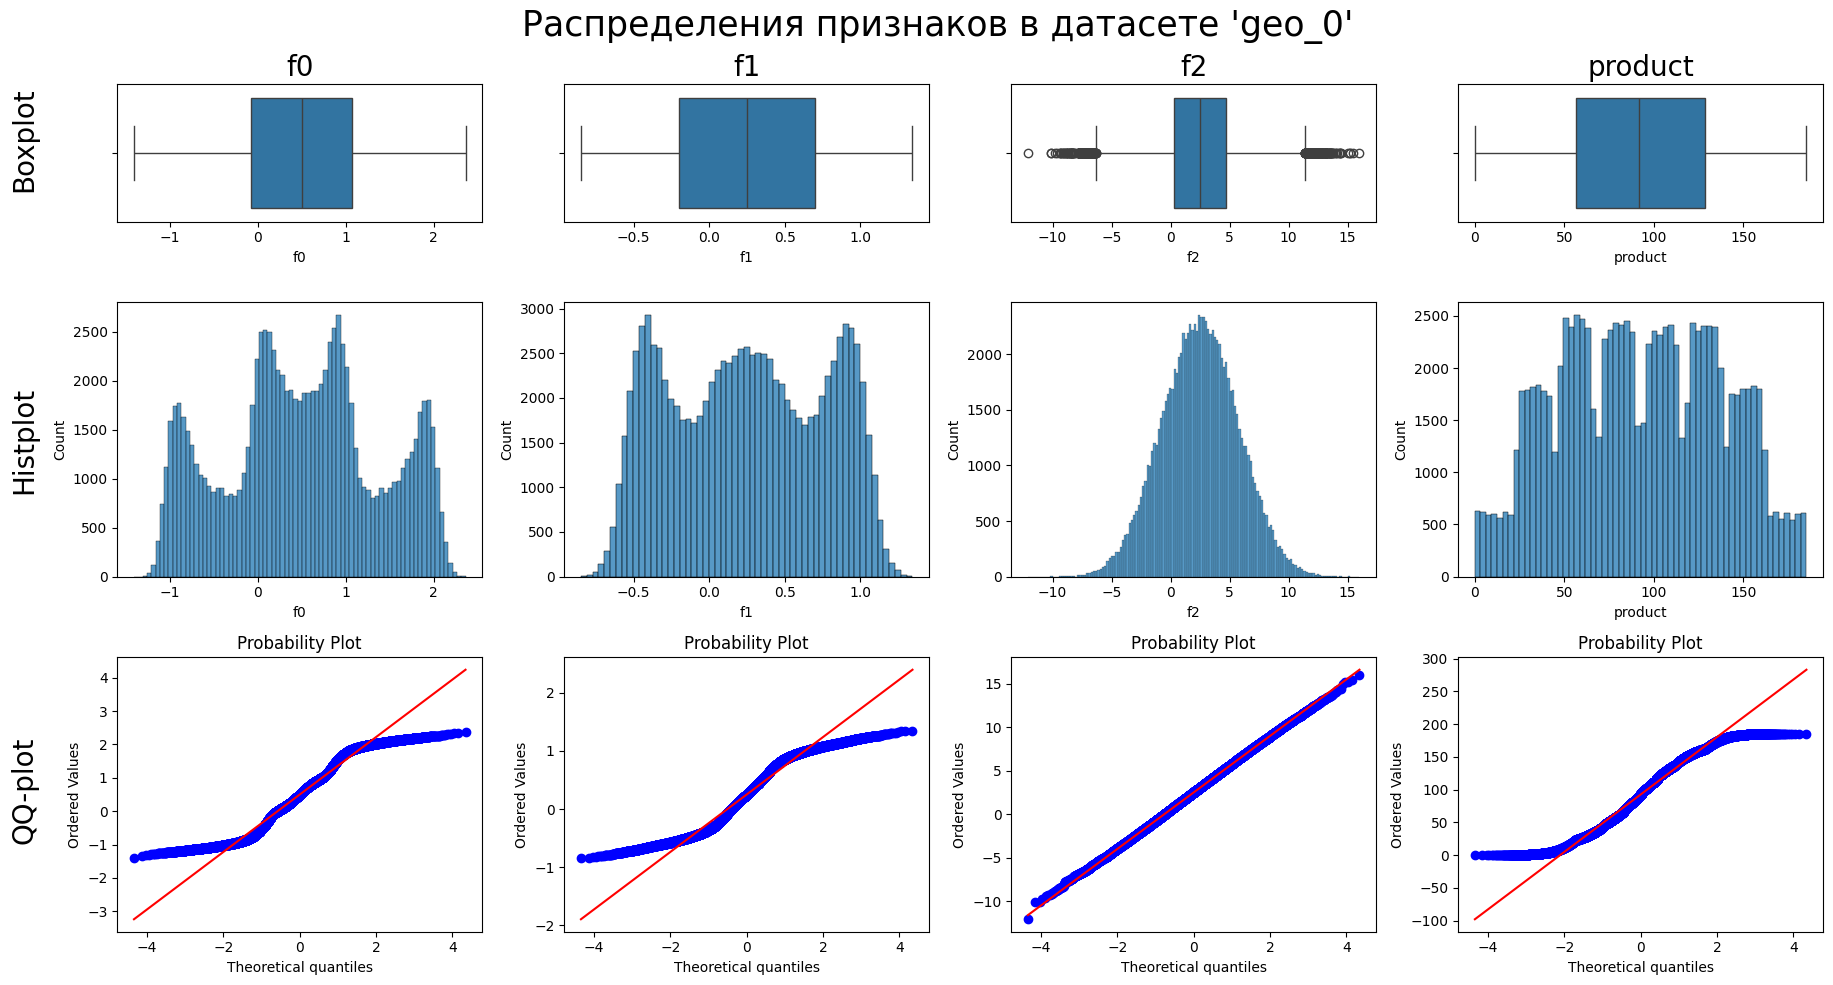

Информация о целевом признаке: 
count    99980.000000
mean        92.499166
std         44.289044
min          0.000000
25%         56.496513
50%         91.847928
75%        128.564089
max        185.364347
Name: product, dtype: float64


In [20]:
feature_distributions(geo_0, 'geo_0')

**Выводы:**
- `f0`: мультимодальное рапределение;
- `f1`: мультимодальное рапределение;
- `f2`: нормальное распределение, боксплот показал допустимые выбросы;
- `product`: мультимодальное рапределение с медианой 92 тыс. баррелей.

### Регион 2

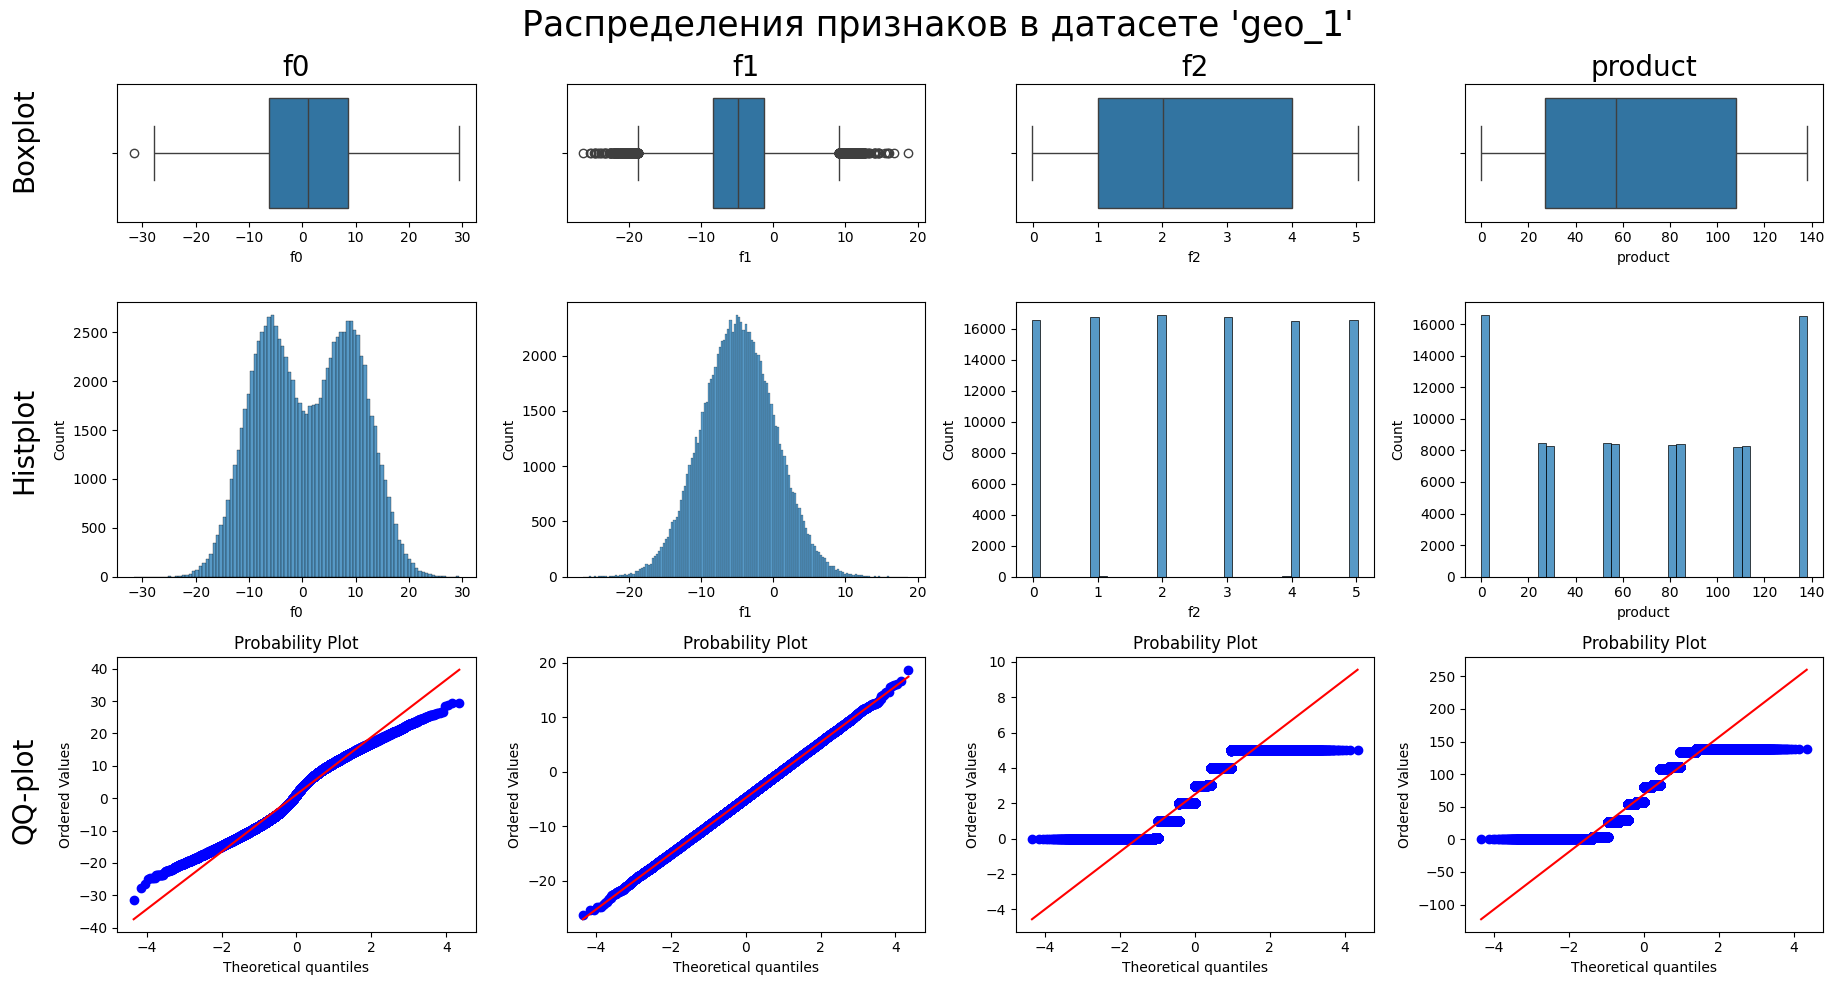

Информация о целевом признаке: 
count    99992.000000
mean        68.824148
std         45.944889
min          0.000000
25%         26.953261
50%         57.085625
75%        107.813044
max        137.945408
Name: product, dtype: float64


In [21]:
feature_distributions(geo_1, 'geo_1')

**Выводы:**
- `f0`: мультимодальное рапределение, один допустимый выброс;
- `f1`: нормальное распределение, боксплот показал допустимые выбросы;
- `f2`: дискретное распределение;
- `product`: дискретное распределение с медианой 57 тыс. баррелей.

### Регион 3

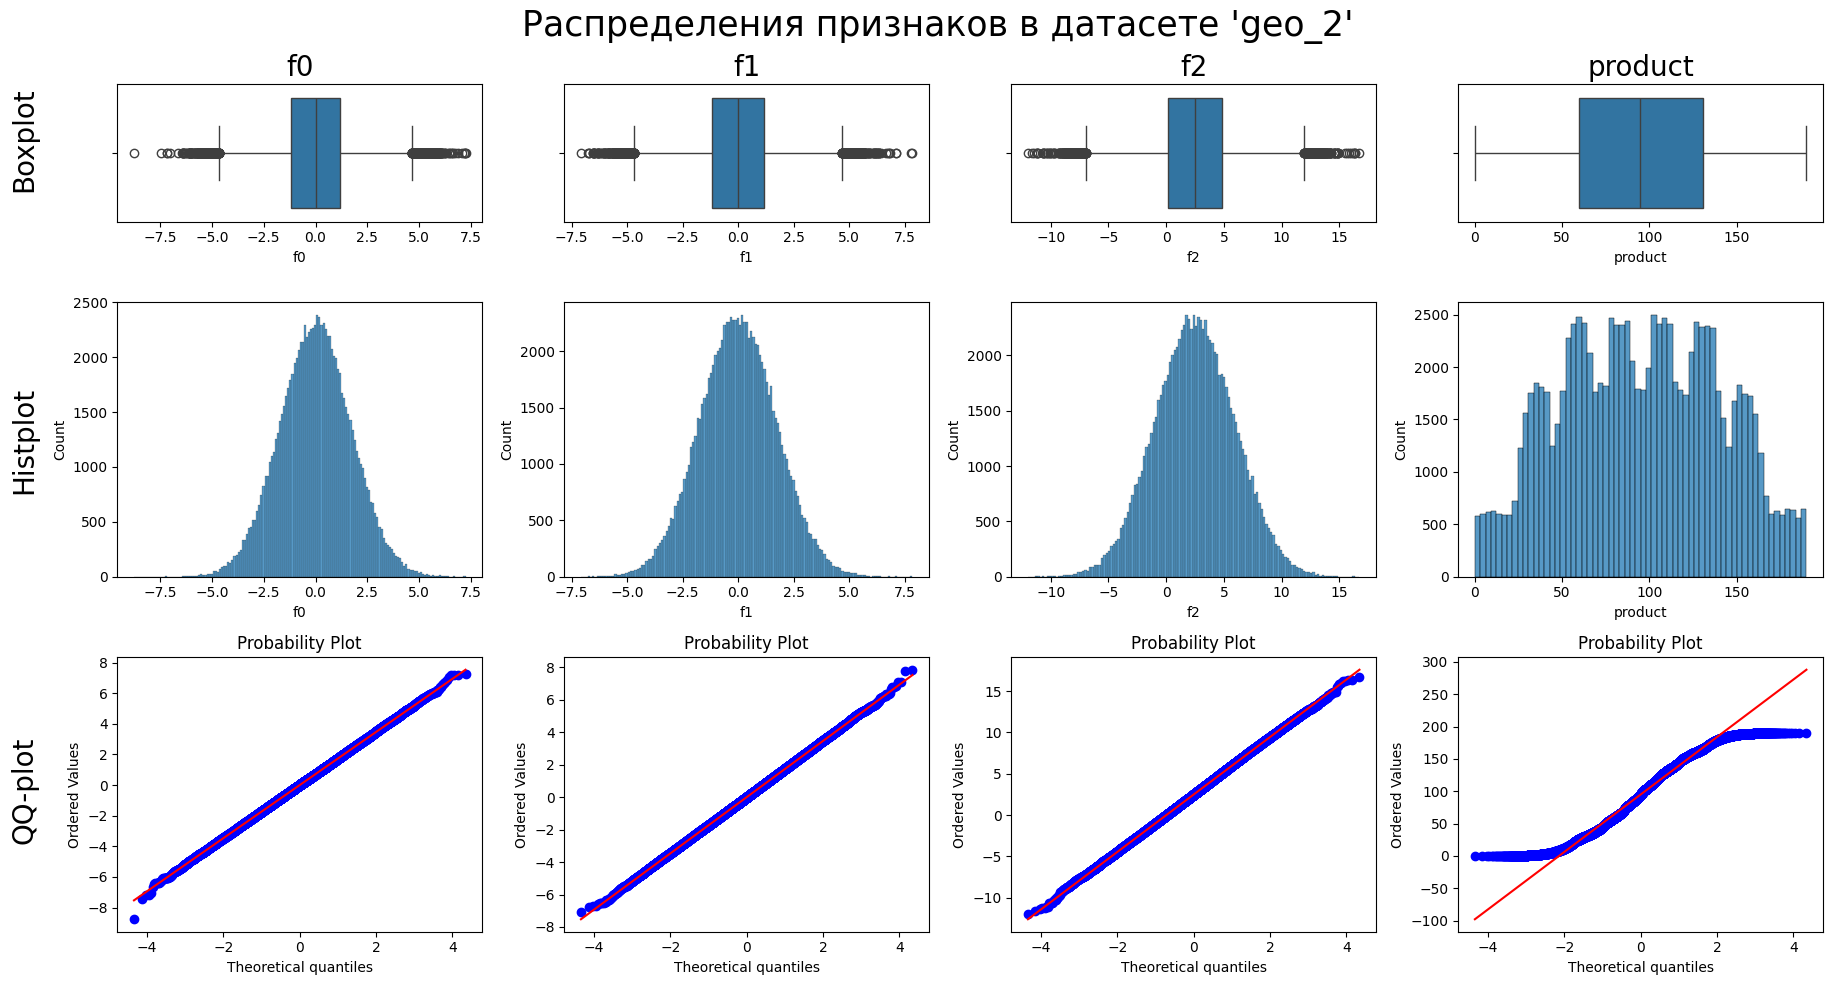

Информация о целевом признаке: 
count    99992.000000
mean        94.998767
std         44.747763
min          0.000000
25%         59.450441
50%         94.925026
75%        130.585544
max        190.029838
Name: product, dtype: float64


In [22]:
feature_distributions(geo_2, 'geo_2')

**Выводы:**
- `f0`: нормальное распределение, боксплот показал допустимые выбросы;
- `f1`: нормальное распределение, боксплот показал допустимые выбросы;
- `f2`: нормальное распределение, боксплот показал допустимые выбросы;
- `product`: мультимодальное рапределение с медианой 95 тыс. баррелей.

## Корреляционный анализ

Для изучения корреляций создадим функцию, выводящую две матрицы. Первая - матрица коэффициентов корреляции фи, вторая - матрица диаграмм рессеяния.

In [23]:
def check_correlations(df):
    
    # Уберем столбец id
    df_ = df.drop(columns = 'id')
    
    # Рассчитаем корреляционную матрицу
    phik_overview = phik_matrix(df_, interval_cols=df.columns.tolist())
    
    # Визуализируем корреляционную матрицу
    plot_correlation_matrix(phik_overview.values,
                        x_labels=phik_overview.columns,
                        y_labels=phik_overview.index,
                        vmin=0, vmax=1, color_map='Blues',
                        title=r'Correlation $\phi_K$',
                        figsize=(8, 7))
    
    # Матрица диаграмм рассеяния
    sns.pairplot(df_, diag_kind="kde", height=1.7)
    plt.show()

### Регион 1

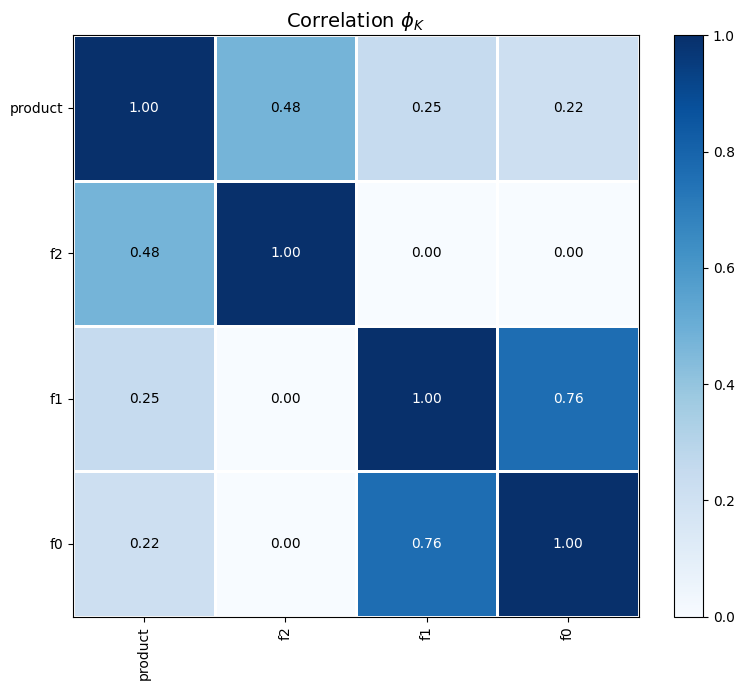

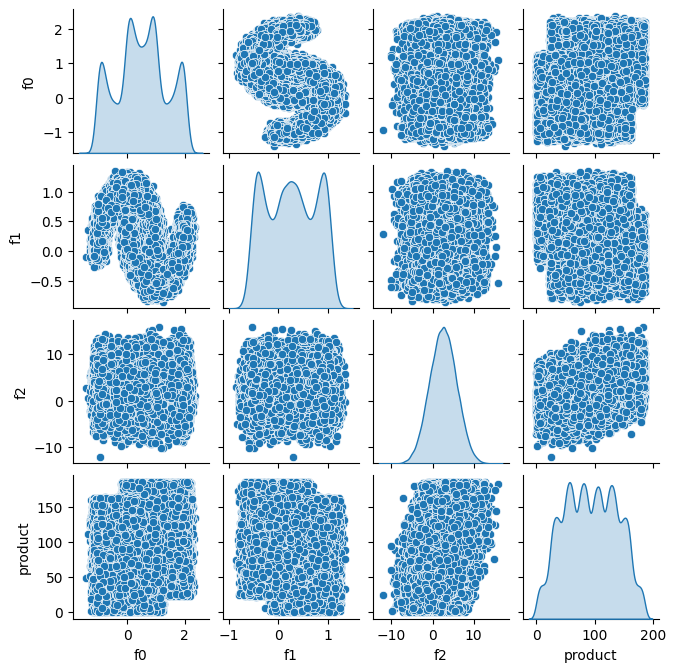

In [24]:
check_correlations(geo_0)

**Вывод:**
- `f0`: коэф.корреляции фи с целевым признаком - 0.22, средняя корреляция, на диаграмме рассеяния видна слоистая структура;
- `f1`: коэф.корреляции фи с целевым признаком - 0, отсутствует корреляция;
- `f2`: коэф.корреляции фи с целевым признаком - 0.48, сильная корреляция, диаграмма рассеяния представляет широкий канал с растущим трендом;
- Признаки `f0` и `f1` имеют сложную нелинейную связь, диаграмма рассеяния показала наличие двух перевернутых частей параболы, коэф.корреляции фи между ними - 0.76.
- Мультиколлинераности нет.

### Регион 2

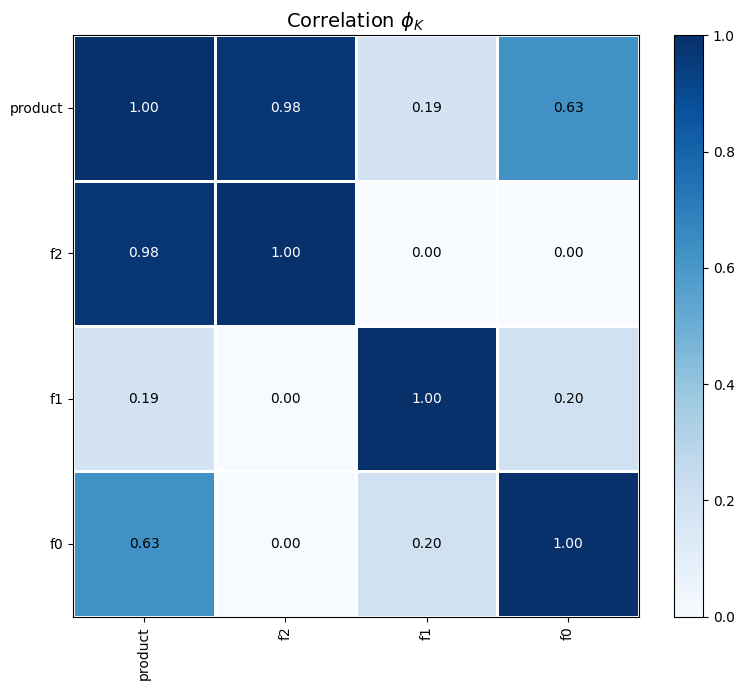

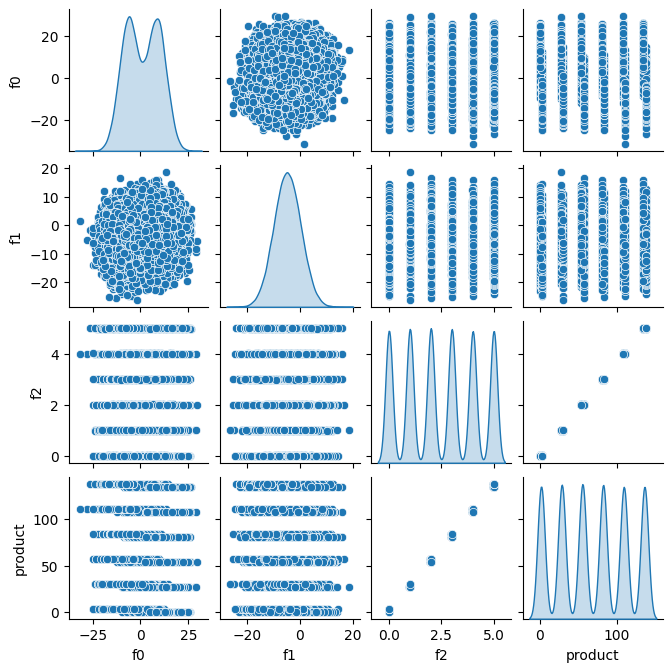

In [25]:
check_correlations(geo_1)

**Вывод:**
- `f0`: коэф.корреляции фи с целевым признаком - 0.63, средняя корреляция, на диаграмме рассеяния видна слоистая структура;
- `f1`: коэф.корреляции фи с целевым признаком - 0.19, слабая корреляция;
- `f2`: коэф.корреляции фи с целевым признаком - 0.98, почти идеальная корреляция, диаграмма рассеяния представляет прямую линию;
- Мультиколлинераности нет.

### Регион 3

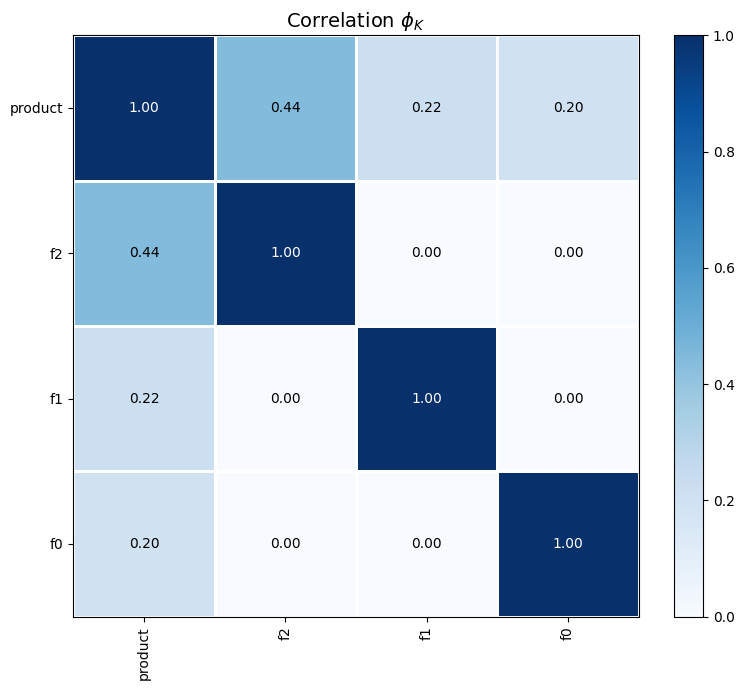

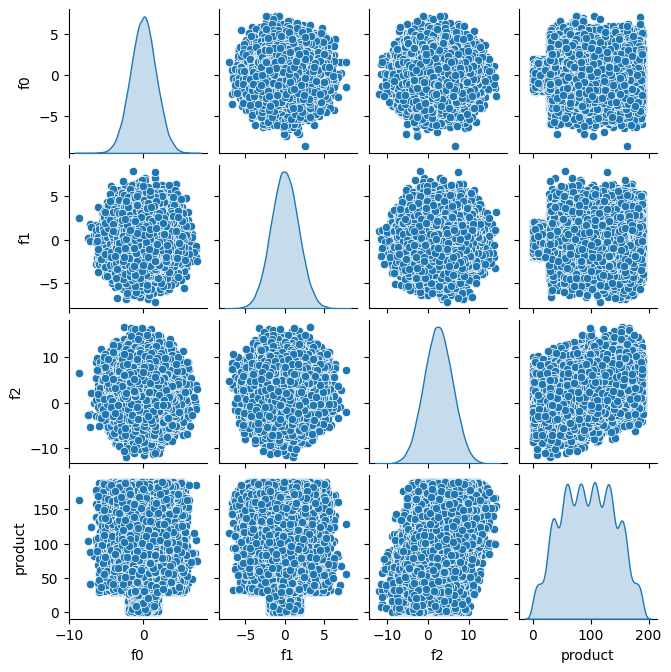

In [26]:
check_correlations(geo_2)

**Вывод:**
- `f0`: коэф.корреляции фи с целевым признаком - 0.20, слабая корреляция;
- `f1`: коэф.корреляции фи с целевым признаком - 0.22, слабая корреляция;
- `f2`: коэф.корреляции фи с целевым признаком - 0.44, средняя корреляция, диаграмма рассеяния представляет очень широкий канал с растущим трендом;
- Мультиколлинераности нет.

## Обучение и проверка модели

Создадим функцию, которая будет содержать алгоритм подготовки данных, а также саму модель линейной регрессии. Подготовка представляет из себя резбиение на тренировочную и тестовую выборки в соотношении `3:1`, масштабирование с помощью стандартизации. Подбор гиперпараметров не предусмотрен задачей. Для определения качества моделей используются метрики `rmse` и `r2`, также для сравнения регионов изучается средний объем запасов нефти из предсказанных значений. Все метрики и предсказания сохраняются в переменных, которые возвращает функция.

In [27]:
def linear_regression(df):
    
    # Разбиение на выборки
    X = df.drop(columns = ['id', 'product'])
    y = df['product']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = 0.25,
        random_state=RANDOM_STATE
    )
    
    # Масштабирование признаков с помощью стандартизации
    scaler = StandardScaler()
    X_train_scalled = scaler.fit_transform(X_train)
    X_test_scalled = scaler.transform(X_test)
    
    # Инициация и обучение моделей
    model = LinearRegression()
    model.fit(X_train_scalled, y_train)
    y_pred = pd.Series(model.predict(X_test_scalled), index=X_test.index)
    
    # Подсчет метрик
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    oil_mean = y_pred.mean()
    
    return y_test, y_pred, rmse, r2, oil_mean
    

In [28]:
y_test_0, y_pred_0, rmse_0, r2_0, oil_mean_0 = linear_regression(geo_0)
y_test_1, y_pred_1, rmse_1, r2_1, oil_mean_1 = linear_regression(geo_1)
y_test_2, y_pred_2, rmse_2, r2_2, oil_mean_2 = linear_regression(geo_2)

pd.DataFrame(index = ['geo_0', 'geo_1', 'geo_2'],
            data = {
                'rmse': [rmse_0, rmse_1, rmse_2],
                'pred_mean_volume': [oil_mean_0, oil_mean_1, oil_mean_2],
                'r2': [r2_0, r2_1, r2_2]
            }
            )

,rmse,pred_mean_volume,r2
geo_0,37.761147,92.286539,0.272054
geo_1,0.892864,69.168941,0.999623
geo_2,40.131156,94.820691,0.194890


**Вывод:**

*Регион 1:*

- Модель показала большую ошибку - `37.76`. 
- Метрика `r2` говорит, что полученная модель всего на `27%` лучше, чем рандомизированная, предсказывающая среднее в каждой итерации. 
- Средний запас предсказанного сырья - `92.29` тыс. баррелей. 

*Регион 2:*
- Модель показала очень маленькую ошибку - `0.89`. 
- Значение метрики `r2` указывает на идеальное качество модели. 
- Если интерпретировать, то это вызвано высокой корреляции признака `f2`. 
- Средний запас предсказанного сырья - `69.17` тыс. баррелей, что является минимальным среди трех регионов, однако модель имеет минимальный разброс.

*Регион 3:*
- Модель показала худшие результаты, `rmse` - `40.13`. 
- Метрика `r2` говорит, что полученная модель всего на `19%` лучше предсказания среднего. 
- Средний запас предсказанного сырья - `94.82` тыс. баррелей, при этом разброс - максимальный.

## Подготовка к расчёту прибыли

In [29]:
scouting = 500 # для разведки региона исследуют 500 скважин
best = 200 # отбирают 200 лучших скважин для разработки
budget = 10_000_000_000 # бюджет на разработку скважин в регионе
price = 450_000 # цена за единицу объема нефти (1000 баррелей)

In [30]:
min_oil_volume = round(budget / price / best, 2)

print(f'Минимально достаточный объём сырья для безубыточной разработки новой скважины {min_oil_volume} тыс. баррелей.')

Минимально достаточный объём сырья для безубыточной разработки новой скважины 111.11 тыс. баррелей.


In [31]:
print('Средний объем сырья в скважине для:')
print('- Региона 1:', round(geo_0['product'].mean(), 2))
print('- Региона 2:', round(geo_1['product'].mean(), 2))
print('- Региона 3:', round(geo_2['product'].mean(), 2))

Средний объем сырья в скважине для:
- Региона 1: 92.5
- Региона 2: 68.82
- Региона 3: 95.0


Как мы видим ни в одном регионе среднее значение не дотягивает до минимального допустимого объема сырья для безубытка. Средний запас сырья в регионе 2 сильно ниже, чем в 1 или 3. При условии, что из 500 случайных выбирают 200 лучших скважин, вероятность получить среднее, превышающее 111.11 тыс. бар., имеется для каждого из регионов.

Посмотрим, сколько скважин со средним объемом, превышающим порог безубытка, в каждом регионе.

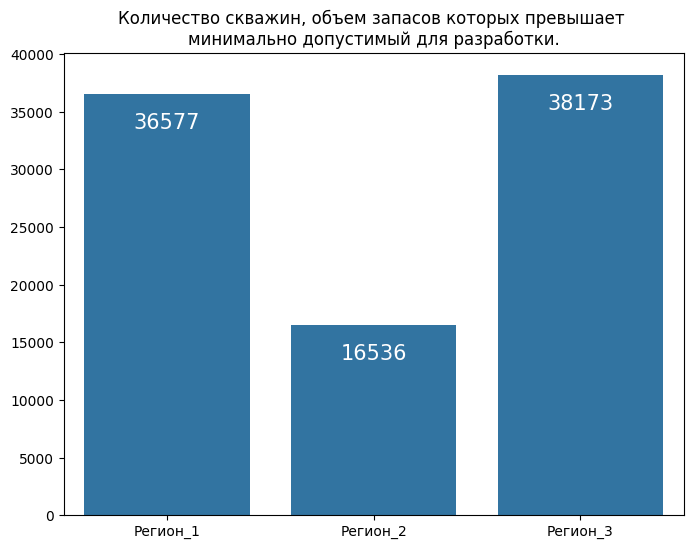

In [32]:
above_min = {}
for df, name in zip([geo_0, geo_1, geo_2], ['Регион_1', 'Регион_2', 'Регион_3']): 
    above_min[name] = (df['product'] > min_oil_volume).sum()
    
plt.figure(figsize=(8, 6))   
sns.barplot(above_min)
plt.title('Количество скважин, объем запасов которых превышает \nминимально допустимый для разработки.')

for key, value in above_min.items():
    plt.text(key, value - 3000, str(value), ha='center', color='white', fontsize = 15)

plt.show()

В регионе №2 таких скважин в более чем 2 раза меньше, чем в других. Это снижает вероятность выбора данного региона для разработки.

## Расчёт прибыли и рисков 

Применим технику `bootstrap` с `1000` выборками. Из предсказанных моделями значений берем `500` случайных скважин. Далее сортируем по убыванию и для `200` первых находим прибыль, исходя из реальных объемов в тестовой выборке, с помощью функции `calculate_profit`. Затем получаем среднее значение прибыли для `1000` выборок, `95%` доверительный интервал. Для расчета риска находим соотношение отрицательных значений прибыли к размеру выборки. Для выбора региона риск не должен превышать `2.5%`.

In [33]:
# Функция расчета реальной прибыли 200 лучших точек среди предсказанных
def calculate_profit(y_test, pred):
    indexes = pred.sort_values(ascending=False)[:best].index
    total_volume = y_test.loc[indexes].sum()
    return  float(total_volume * price - budget)

bootstrap_samples = 1000 # Количество итераций бутстрэпа

def bootstraped_region_profit(y_test, y_pred, name):
    
    subsample_profit=[] # Список для хранения прибыли каждой бутстрэп-итерации
    state = np.random.RandomState(123) # Генератор случайных чисел с фиксированным seed
    
    # Проведение техники бутстреп
    for i in range(bootstrap_samples):
        subsample = y_pred.sample(n = scouting, replace = True, random_state=state)
        subsample_profit.append(calculate_profit(y_test, subsample))

    subsample_profit = pd.Series(subsample_profit) # Преобразуем список в Series для удобного анализа
    
    # Расчет среднего, 95% доверительного интервала и рисков
    mean = subsample_profit.mean()
    conf_interval = np.quantile(subsample_profit, [0.025, 0.975])
    risk = (subsample_profit < 0).mean()
    
    # Вывод результатов
    print(name)
    print(f'Среднее: {mean:_.0f}')
    print(f'95% доверительный интервал: от {conf_interval[0]:_.0f} до {conf_interval[1]:_.0f}')
    print(f'Риск убытка: {risk:.2%}')
    
    # Визуализация распределения прибыли
    plt.figure(figsize=(8, 6))
    sns.histplot(subsample_profit, label = name)
    plt.axvline(conf_interval[0], color = 'black', linestyle = '--', linewidth = 2, label = '95% conf. int.')
    plt.axvline(conf_interval[1], color = 'black', linestyle = '--', linewidth = 2)
    plt.axvline(mean, color = 'red', linestyle = '--', linewidth = 2, label = 'Mean')
    plt.legend()
    plt.show()

Регион_1
Среднее: 383_117_763
95% доверительный интервал: от -109_006_767 до 904_324_595
Риск убытка: 7.70%


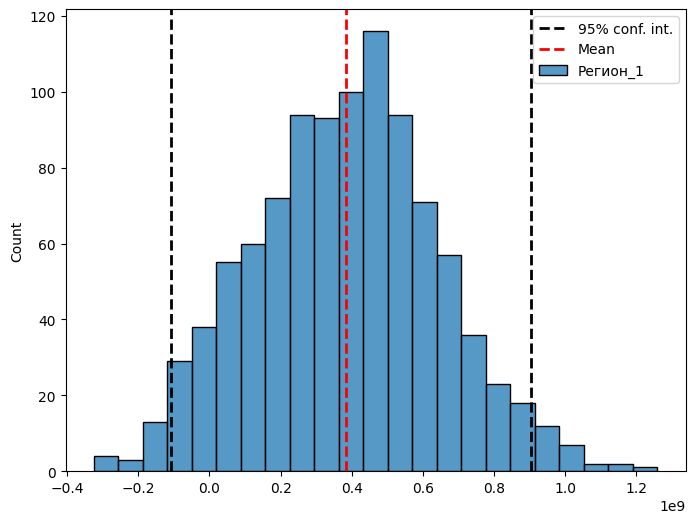

In [34]:
bootstraped_region_profit(y_test_0, y_pred_0, 'Регион_1')

Регион_2
Среднее: 494_038_070
95% доверительный интервал: от 110_111_715 до 918_017_573
Риск убытка: 0.40%


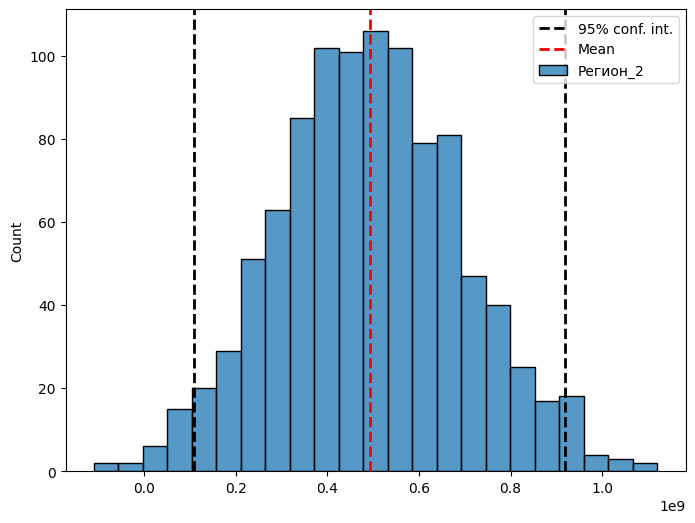

In [35]:
bootstraped_region_profit(y_test_1, y_pred_1, 'Регион_2')

Регион_3
Среднее: 344_912_384
95% доверительный интервал: от -207_448_274 до 874_329_718
Риск убытка: 9.90%


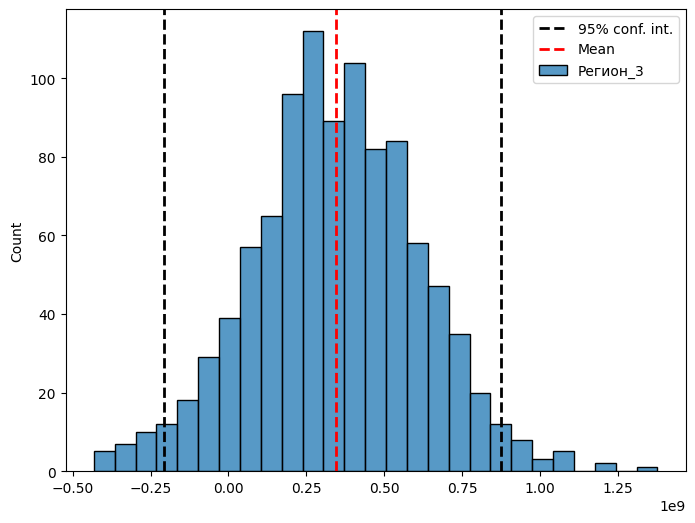

In [36]:
bootstraped_region_profit(y_test_2, y_pred_2, 'Регион_3')

**Вывод:**

- Для разработки рекомендуется выбрать `регион №2` (предоставленные данные - `geo_1`). 
- Интересно, что данный регион не отличался высоким показателем средних запасов сырья и был последним в списке.
- Сейчас в нем ожидается максимальная средняя прибыль почти `500 млн.руб`, что выше остальных более чем на `100 млн.руб`. 
- Благодаря высокой корреляции признака `f2` с целевым, была получена модель с идеальной предсказательной способностью. 
- Это позволило достоверно выбрать `200` лучших скважин, сведя риск почти к нулю - `0.4%`.
- Сейчас `регион №2` - единственный, у которого риск понести убытки менее `2.5%`.
- Также важно учесть, что нижняя граница `95%` доверительного интервала лежит в положительной области, тогда как у других - в отрицательной.


## Вывод

<span style="font-size:20px; font-weight:500;">Цель:</span>

- Нужно решить, где бурить новую скважину. 

<span style="font-size:20px; font-weight:500;">Задачи:</span>
1. Построить модель машинного обучения, которая поможет определить регион, где добыча нефти принесет наибольшую прибыль.
2. Проанализировать возможную прибыль и риски техникой `Bootstrap`.


<span style="font-size:20px; font-weight:500;">Этапы работы:</span>

1. Предобработка данных - Были изучены датасеты на наличие пропусков и дубликатов. Вторые были обнаружены и удалены. 
2. Исследовательский анализ -  Проведены исследования признаков и их влияния на тергеты.
3. Корреляционный анализ - Выявлены основные зависимости признаков. Данные проверены на мультиколлинеарность.
4. Подготовка данных - Данные разбили на выборки. Подготовлена функция для масштабирования признаков и обучения модели с помощью `LinearRegression()`.
5. Обучение моделей - Получены и сохранены в переменные результаты работы моделей на каждом регионе. 
6. Подготовка к расчету прибыли - Были заданы все необходимые константы. Получен минимально необходимый объем сырья для безубытка.
7. Расчет прибыли и рисков - Созданы и применены функции подсчета прибыли и рисков. Данные визуалированы.


<span style="font-size:20px; font-weight:500;">Описание работы моделей:</span>

*Регион 1:*

- Модель показала большую ошибку - `37.76`. 
- Метрика `r2` говорит, что полученная модель всего на `27%` лучше, чем рандомизированная, предсказывающая среднее в каждой итерации. 
- Средний запас предсказанного сырья - `92.29` тыс. баррелей. 

*Регион 2:*
- Модель показала очень маленькую ошибку - `0.89`. 
- Значение метрики `r2` указывает на идеальное качество модели. 
- Если интерпретировать, то это вызвано высокой корреляции признака `f2`. 
- Средний запас предсказанного сырья - `69.17` тыс. баррелей, что является минимальным среди трех регионов, однако модель имеет минимальный разброс.

*Регион 3:*
- Модель показала худшие результаты, `rmse` - `40.13`. 
- Метрика `r2` говорит, что полученная модель всего на `19%` лучше предсказания среднего. 
- Средний запас предсказанного сырья - `94.82` тыс. баррелей, при этом разброс - максимальный.


<span style="font-size:20px; font-weight:500;">Рекомендуемый регион:</span>

- `Регион №2`, данные взяты из `geo_1`.


<span style="font-size:20px; font-weight:500;">Обоснование выбора:</span>
- Интересно, что данный регион не отличался высоким показателем средних запасов сырья и был последним в списке.
- Сейчас в нем ожидается максимальная средняя прибыль почти `500 млн.руб`, что выше остальных более чем на `100 млн.руб`. 
- Благодаря высокой корреляции признака `f2` с целевым, была получена модель с идеальной предсказательной способностью. 
- Это позволило достоверно выбрать `200` лучших скважин, сведя риск почти к нулю - `0.4%`.
- Сейчас `регион №2` - единственный, у которого риск понести убытки менее `2.5%`.
- Также важно учесть, что нижняя граница `95%` доверительного интервала лежит в положительной области, тогда как у других - в отрицательной.
